C:\Users\skhabaz\AppData\Local\Temp\ipykernel_20184\4031214192.py:23: DtypeWarning: Columns (0: PRN, 1: Unnamed: 1, 2: Unnamed: 2, 3: Unnamed: 3, 4: Unnamed: 4, 5: Unnamed: 5, 6: Unnamed: 6, 7: Unnamed: 7, 8: Carrier_Doppler_hz, 9: Unnamed: 9, 10: Unnamed: 10, 11: Unnamed: 11, 12: Unnamed: 12, 13: Unnamed: 13, 14: Unnamed: 14, 15: Unnamed: 15, 16: Pseudorange_m, 17: Unnamed: 17, 18: Unnamed: 18, 19: Unnamed: 19, 20: Unnamed: 20, 21: Unnamed: 21, 22: Unnamed: 22, 23: Unnamed: 23, 24: RX_time, 25: Unnamed: 25, 26: Unnamed: 26, 27: Unnamed: 27, 28: Unnamed: 28, 29: Unnamed: 29, 30: Unnamed: 30, 31: Unnamed: 31, 32: TOW_at_current_symbol_s, 33: Unnamed: 33, 34: Unnamed: 34, 35: Unnamed: 35, 36: Unnamed: 36, 37: Unnamed: 37, 38: Unnamed: 38, 39: Unnamed: 39, 40: Carrier_phase_cycles, 41: Unnamed: 41, 42: Unnamed: 42, 43: Unnamed: 43, 44: Unnamed: 44, 45: Unnamed: 45, 46: Unnamed: 46, 47: Unnamed: 47, 48: EC, 49: Unnamed: 49, 50: Unnamed: 50, 51: Unnamed: 51, 52: Unnamed: 52, 53: Unnamed: 53

    Fichiers chargés
   df1 — GPS_Authentic  : 159,146 lignes × 104 colonnes
   df2 — GPS_Simplified : 510,530 lignes × 14 colonnes
   df3 — GPS_Full       : 158,176 lignes × 112 colonnes
 df1 — GPS_Authentic (5 premières lignes) :
 df1 — GPS_Authentic (5 premières lignes) :
 df2 — GPS_Simplified (5 premières lignes) :
 df3 — GPS_Full (5 premières lignes) :


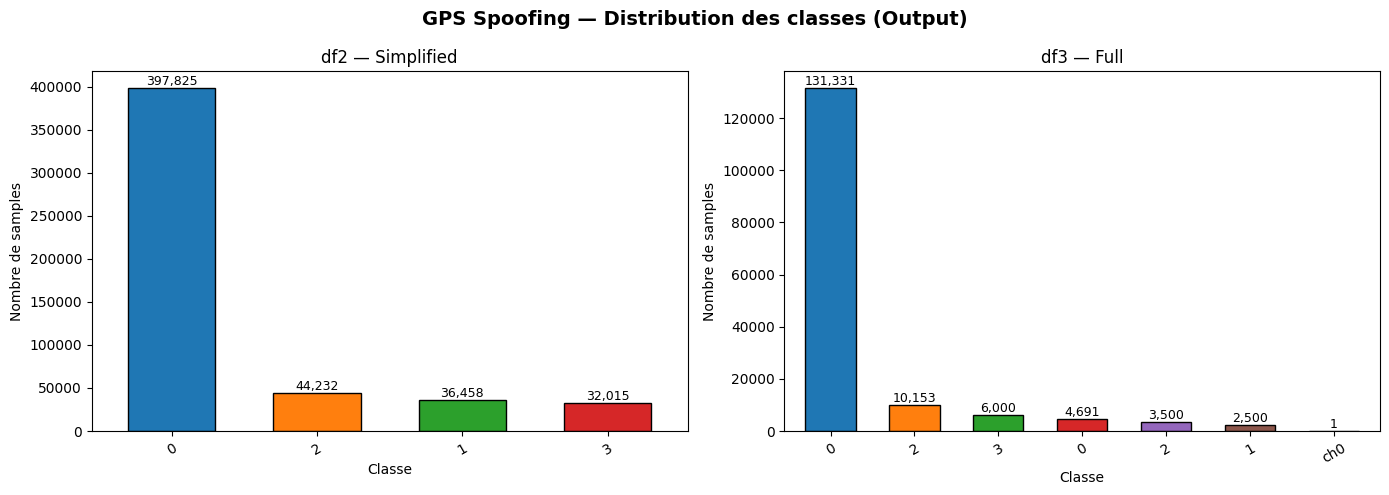


 df2 — Distribution Output :
Output
0    397825
2     44232
1     36458
3     32015
Name: count, dtype: int64

 df3 — Distribution Output :
Output
0      131331
2       10153
3        6000
0        4691
2        3500
1        2500
ch0         1
Name: count, dtype: int64
 df1 — Aucune valeur manquante

 df2 — Aucune valeur manquante

 df3 — Aucune valeur manquante

🔢 df2 — 13 features : ['PRN', 'DO', 'PD', 'RX', 'TOW', 'CP', 'EC', 'LC', 'PC', 'PIP', 'PQP', 'TCD', 'CN0']


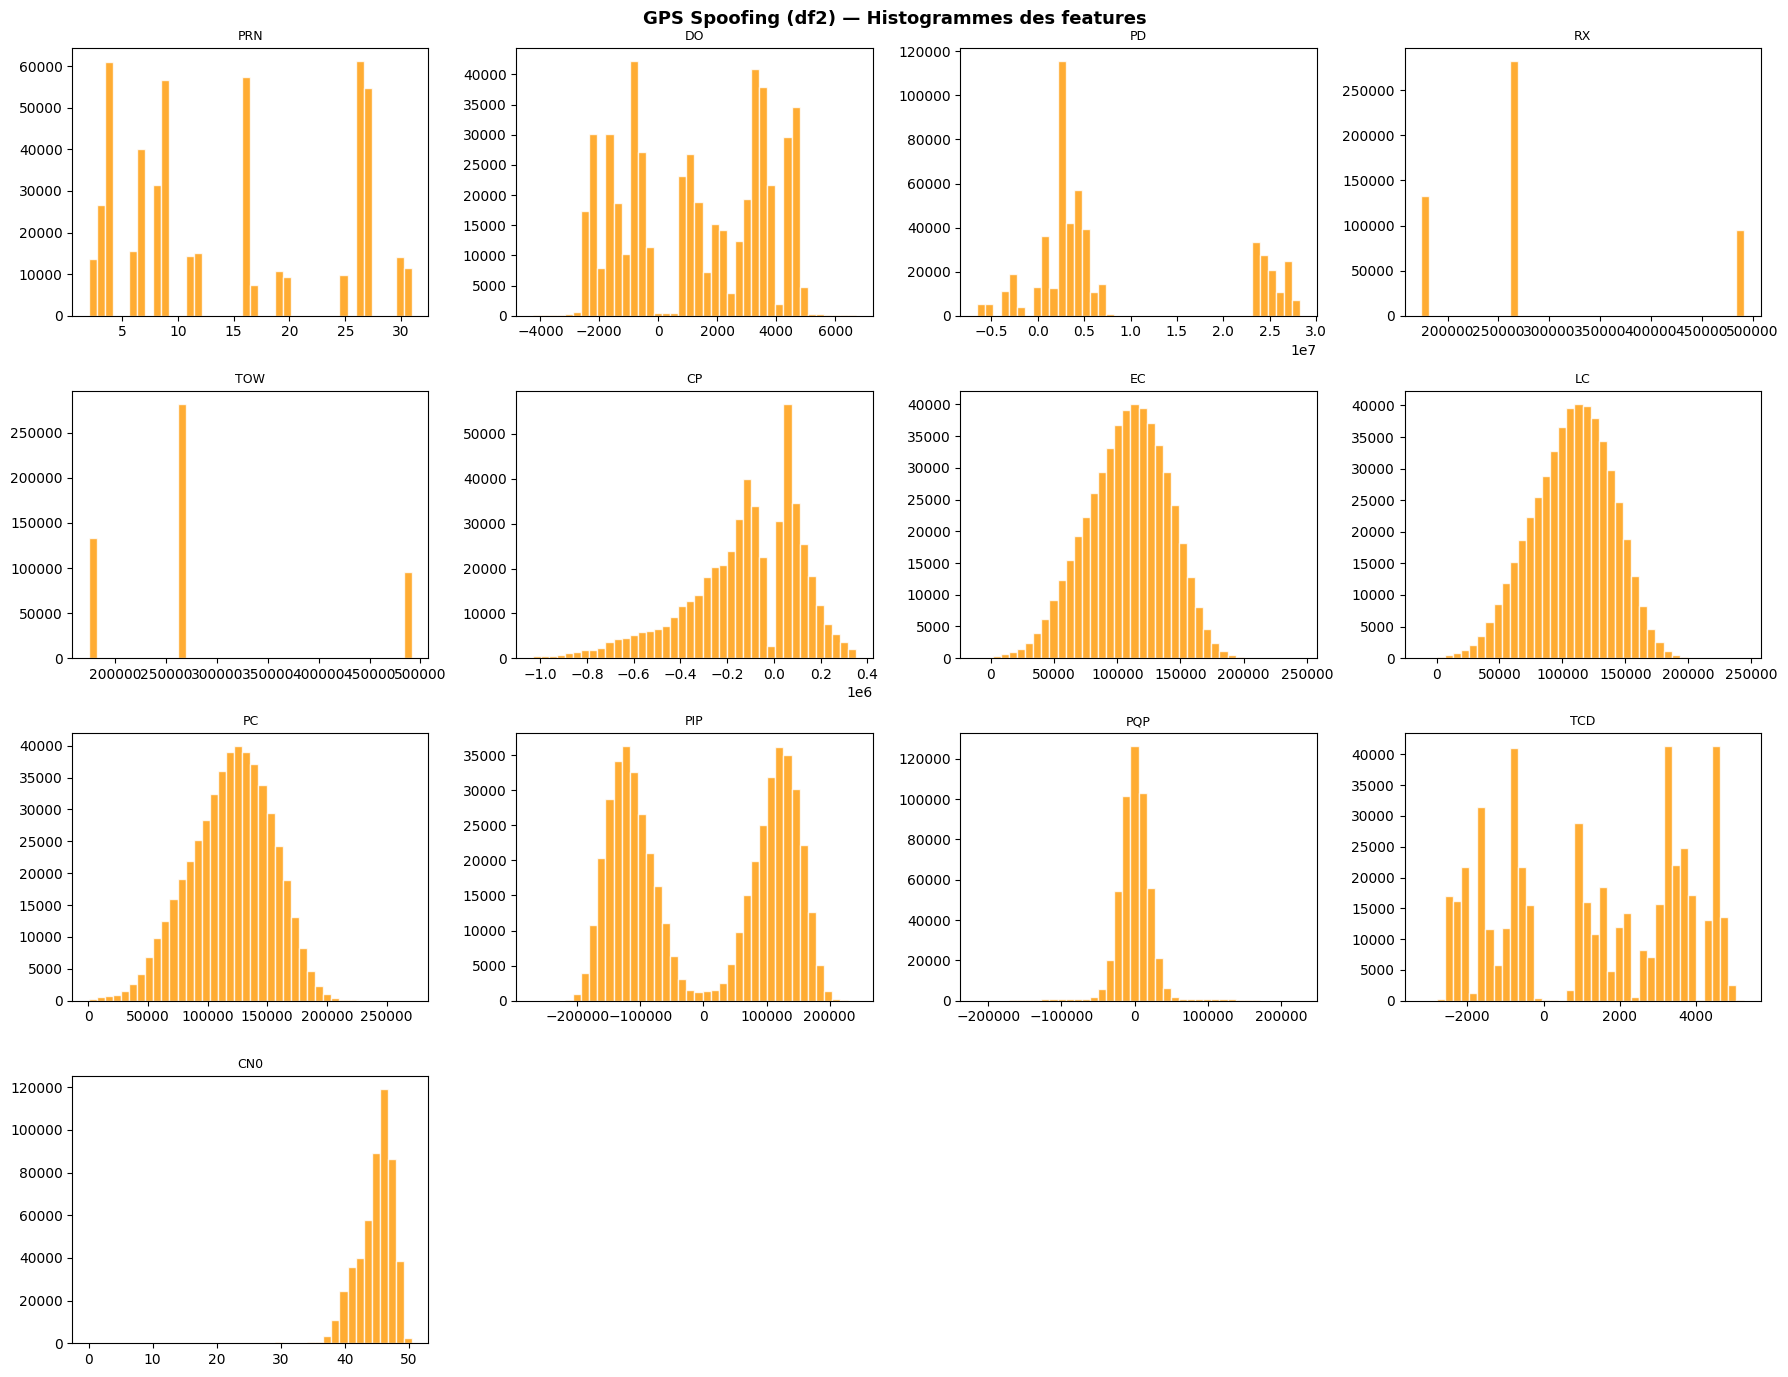

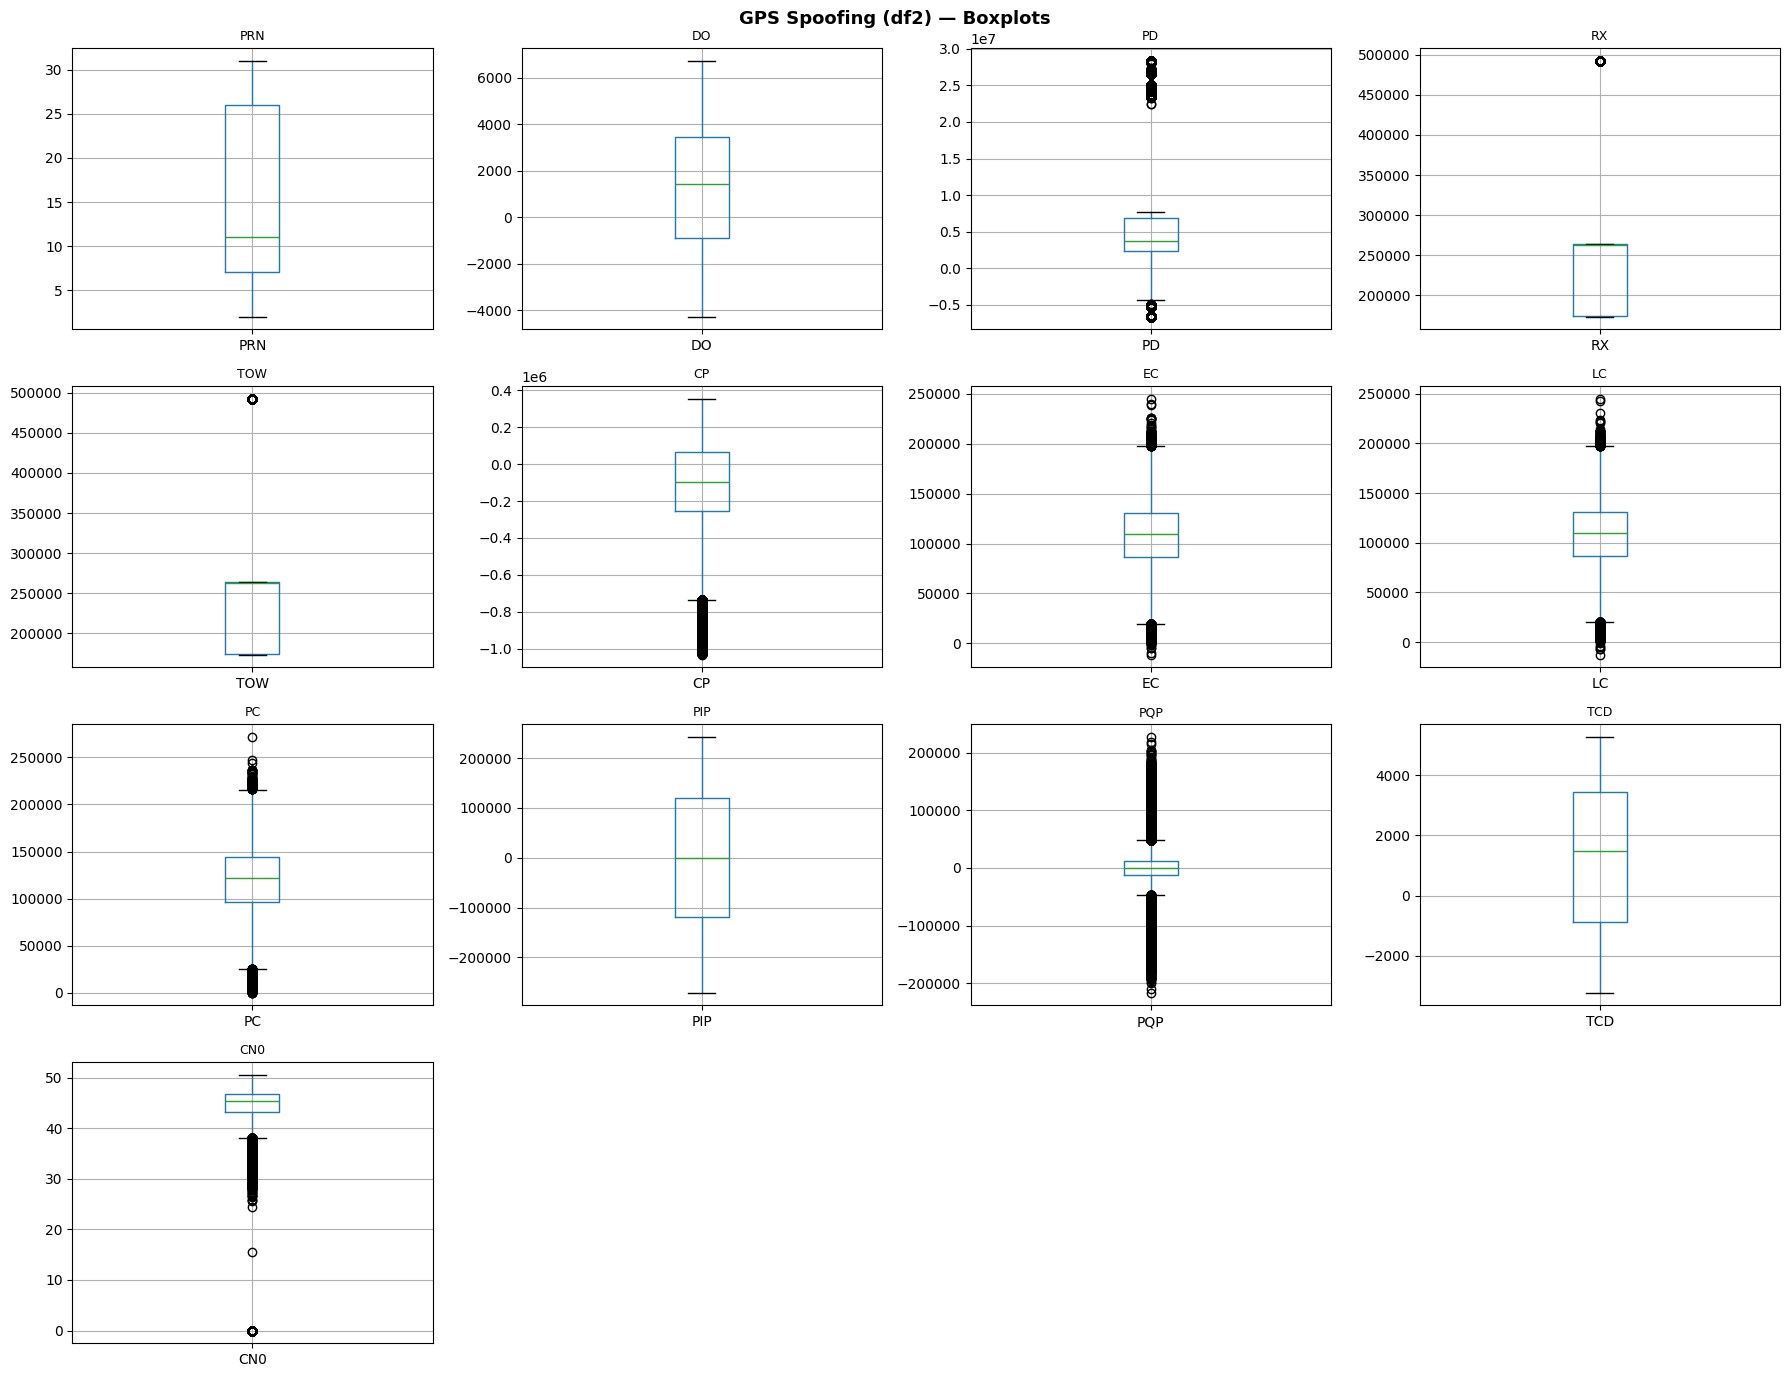

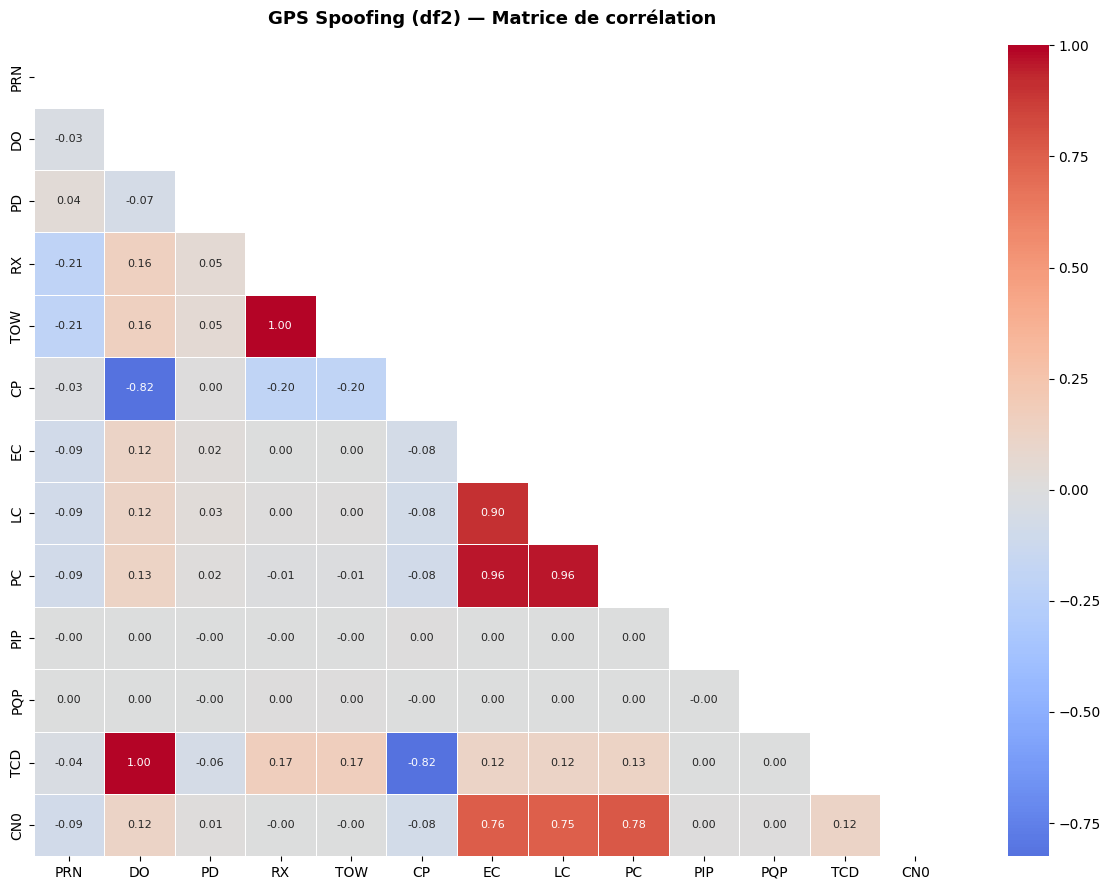

In [ ]:
# ============================================================
# NOTEBOOK : Exploration des données — GPS Spoofing
# Dataset  : Signal-level GPS attack captures
# ============================================================

# ────────────────────────────────────────
# 1. IMPORTATION DES LIBRAIRIES
# ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ────────────────────────────────────────
# 2. CHARGEMENT DES CSV
# ────────────────────────────────────────
PATH = r"C:\Drone_Attack_Similarity_Project\DATASET\GPS_Spoofing"

df1 = pd.read_csv(os.path.join(PATH, "GPS_Authentic.csv"))
df2 = pd.read_csv(os.path.join(PATH, "GPS_Simplified.csv"))
df3 = pd.read_csv(os.path.join(PATH, "GPS_Full.csv"))

print("    Fichiers chargés")
print(f"   df1 — GPS_Authentic  : {df1.shape[0]:,} lignes × {df1.shape[1]} colonnes")
print(f"   df2 — GPS_Simplified : {df2.shape[0]:,} lignes × {df2.shape[1]} colonnes")
print(f"   df3 — GPS_Full       : {df3.shape[0]:,} lignes × {df3.shape[1]} colonnes")

# ────────────────────────────────────────
# 3. APERÇU GÉNÉRAL DES 3 FICHIERS
# ────────────────────────────────────────
print(" df1 — GPS_Authentic (5 premières lignes) :")
df1.head()

# ────────────────────────────────────────
# 3. APERÇU GÉNÉRAL DES 3 FICHIERS
# ────────────────────────────────────────
print(" df1 — GPS_Authentic (5 premières lignes) :")
df1.head()

print(" df2 — GPS_Simplified (5 premières lignes) :")
df2.head()

print(" df3 — GPS_Full (5 premières lignes) :")
df3.head()

# ────────────────────────────────────────
# 4. DISTRIBUTION DES CLASSES
# ────────────────────────────────────────
# df1 n'a pas de label — uniquement df2 et df3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GPS Spoofing — Distribution des classes (Output)",
             fontsize=14, fontweight='bold')

for ax, (name, df) in zip(axes, [("df2 — Simplified", df2),
                                   ("df3 — Full",       df3)]):
    counts = df['Output'].value_counts()
    colors = sns.color_palette("tab10", n_colors=len(counts))
    counts.plot(kind='bar', ax=ax, color=colors,
                edgecolor='black', width=0.6)
    ax.set_title(name)
    ax.set_xlabel("Classe")
    ax.set_ylabel("Nombre de samples")
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5,
                f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("GPS_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n df2 — Distribution Output :")
print(df2 ['Output'].value_counts())
print(f"\n df3 — Distribution Output :")
print(df3['Output'].value_counts())


# ────────────────────────────────────────
# 5. ANALYSE DES VALEURS MANQUANTES
# ────────────────────────────────────────
for name, df in [("df1", df1), ("df2", df2), ("df3", df3)]:
    total = df.isnull().sum().sum()
    if total > 0:
        print(f"  {name} — {total} valeurs manquantes :")
        print(df.isnull().sum()[df.isnull().sum() > 0])
    else:
        print(f" {name} — Aucune valeur manquante")
    print()

# ────────────────────────────────────────
# 6. DISTRIBUTION DES FEATURES — df2
# ────────────────────────────────────────
num_cols_df2 = [c for c in df2.select_dtypes(include=[np.number]).columns
                if c != 'Output']
print(f" df2 — {len(num_cols_df2)} features : {num_cols_df2}")

# 4x4 = 16 cases — suffisant pour 13 features
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle("GPS Spoofing (df2) — Histogrammes des features",
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
for i, col in enumerate(num_cols_df2):
    axes_flat[i].hist(df2[col].dropna(), bins=40,
                      color='#FF9800', edgecolor='white', alpha=0.8)
    axes_flat[i].set_title(col, fontsize=9)

for j in range(len(num_cols_df2), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("GPS_histogrammes.png", dpi=150, bbox_inches='tight')
plt.show()


# ────────────────────────────────────────
# 7. BOXPLOTS — DÉTECTION DES OUTLIERS
# ────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(18, 14))  # ← 4x4 aussi ici
fig.suptitle("GPS Spoofing (df2) — Boxplots",
             fontsize=13, fontweight='bold')

axes_flat = axes.flatten()
for i, col in enumerate(num_cols_df2):
    df2.boxplot(column=col, ax=axes_flat[i])
    axes_flat[i].set_title(col, fontsize=9)
    axes_flat[i].set_xlabel("")

for j in range(len(num_cols_df2), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig("GPS_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

# ────────────────────────────────────────
# 8. MATRICE DE CORRÉLATION — df2
# ────────────────────────────────────────
corr = df2[num_cols_df2].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.4,
            annot_kws={"size": 8})
plt.title("GPS Spoofing (df2) — Matrice de corrélation",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("GPS_correlation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
